## 1. Environment Setup

In [ ]:
# Install required packages
!pip install -q pycocotools albumentations

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

PyTorch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126


In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():

    torch.backends.cuda.matmul.fp32_precision = 'ieee'
    torch.backends.cudnn.allow_tf32 = True


    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9

    if 'A100' in gpu_name:
        BATCH_SIZE = 128
        NUM_WORKERS = 12
        print(f"A100 {int(gpu_memory)}GB Optimized: Batch {BATCH_SIZE}, Workers {NUM_WORKERS}")
    else:
        BATCH_SIZE = 128
        NUM_WORKERS = 12

print(f"Batch size: {BATCH_SIZE}")

Batch size: 128


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## 2. Dataset Configuration

In [ ]:
drive.mount("/content/drive", force_remount=True)

NameError: name 'drive' is not defined

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root = '/content/drive/MyDrive'
data_path = os.path.join(root, 'colab_data','coco_top_12_cls')

In [ ]:
train_dir = os.path.join(data_path, 'train')
train_ann = os.path.join(data_path, 'train', '_annotations.coco.json')

valid_dir = os.path.join(data_path, 'valid')
valid_ann = os.path.join(data_path, 'valid', '_annotations.coco.json')

test_dir = os.path.join(data_path, 'test')
test_ann = os.path.join(data_path, 'test', '_annotations.coco.json')

for path in [train_ann, valid_ann, test_ann]:
    if os.path.exists(path):
        print("Found")
    else:
        print(f"Missing: {path}")

In [ ]:
coco_train = COCO(train_ann)
coco_valid = COCO(valid_ann)

categories = coco_train.loadCats(coco_train.getCatIds())
category_names = {cat['id']: cat['name'] for cat in categories}
NUM_CLASSES = len(categories) + 1

print(f"\nNumber of classes (including background): {NUM_CLASSES}")
print(f"\nCategories:")
for cat_id, name in category_names.items():
    print(f"  {cat_id}: {name}")

In [ ]:
# Analyze class distribution
def get_class_distribution(coco):
    ann_ids = coco.getAnnIds()
    anns = coco.loadAnns(ann_ids)

    class_counts = defaultdict(int)
    for ann in anns:
        class_counts[ann['category_id']] += 1
    return class_counts

train_dist = get_class_distribution(coco_train)
valid_dist = get_class_distribution(coco_valid)

print("\nClass Distribution")
print(f"{'Class Name':<35} {'Train':>8} {'Valid':>8}")
print("-" * 55)

total_train, total_valid = 0, 0
for cat_id in sorted(category_names.keys()):
    name = category_names[cat_id]
    train_count = train_dist.get(cat_id, 0)
    valid_count = valid_dist.get(cat_id, 0)
    total_train += train_count
    total_valid += valid_count
    print(f"{name:<35} {train_count:>8} {valid_count:>8}")

print("-" * 55)
print(f"{'Total':<35} {total_train:>8} {total_valid:>8}")

In [ ]:
class_weights = {}
max_count = max(train_dist.values())
for cat_id, count in train_dist.items():
    class_weights[cat_id] = max_count / count

print("\n=== Class Weights (for imbalance) ===")
for cat_id in sorted(class_weights.keys()):
    print(f"{category_names[cat_id]:<35}: {class_weights[cat_id]:.2f}")

## 3. Custom COCO Dataset with Augmentation

In [ ]:
class CandlestickDataset(Dataset):
    def __init__(self, img_dir, ann_file, transforms=None):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')
        img = np.array(img)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if self.transforms:
            if len(boxes) > 0:
                transformed = self.transforms(
                    image=img,
                    bboxes=boxes,
                    labels=labels
                )
                img = transformed['image']
                boxes = transformed['bboxes']
                labels = transformed['labels']
            else:
                transformed = self.transforms(image=img, bboxes=[], labels=[])
                img = transformed['image']

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id]),
            'area': areas,
            'iscrowd': iscrowd
        }

        return img, target

In [ ]:
def get_train_transforms():
    return A.Compose([
        A.RandomBrightnessContrast(p=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'], min_visibility=0.3))

def get_valid_transforms():
    return A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))


In [ ]:
train_dataset = CandlestickDataset(train_dir, train_ann, get_train_transforms())
valid_dataset = CandlestickDataset(valid_dir, valid_ann, get_valid_transforms())
test_dataset = CandlestickDataset(test_dir, test_ann, get_valid_transforms())

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

In [ ]:
def collate_fn(batch):
    images = []
    targets = []
    for img, target in batch:
        images.append(img)
        targets.append(target)
    return images, targets

In [ ]:
sample_weights = []

for img_id in train_dataset.ids:
    ann_ids = coco_train.getAnnIds(imgIds=img_id)
    anns = coco_train.loadAnns(ann_ids)

    if len(anns) > 0:
        current_weights = [class_weights.get(ann['category_id'], 1.0) for ann in anns]
        weight = max(current_weights)
    else:
        weight = 1.0

    sample_weights.append(weight)

sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)

In [17]:
from torch.utils.data import WeightedRandomSampler

In [ ]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,      
    shuffle=False,        
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 53
Valid batches: 15
Test batches: 8


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 4. Model Setup - Faster R-CNN with Frozen Backbone

In [21]:
from torchvision.models.detection.anchor_utils import AnchorGenerator

In [ ]:
def create_model(num_classes, freeze_backbone=True):

    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'backbone' in name:
                param.requires_grad = False
        print("✓ Backbone frozen (transfer learning mode)")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")
    print(f"Trainable %: {100 * trainable_params / total_params:.2f}%")

    return model

model = create_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 198MB/s]


✓ Backbone frozen (transfer learning mode)
Total parameters: 43,312,528
Trainable parameters: 16,458,064
Frozen parameters: 26,854,464
Trainable %: 38.00%


## 5. Training with Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.early_stop

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, scaler):
    model.train()
    total_loss = 0
    num_batches = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += losses.item()
        num_batches += 1

        if num_batches % 50 == 0:
            print(f"  Batch {num_batches}/{len(data_loader)}, Loss: {losses.item():.4f}")

    return total_loss / num_batches


@torch.no_grad()
def evaluate(model, data_loader, device):
    model.train()  
    total_loss = 0
    num_batches = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        total_loss += losses.item()
        num_batches += 1

    return total_loss / num_batches

In [ ]:
epochs = 30
rate = 0.005
weight = 1e-4

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=rate, weight=weight)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
scaler = torch.amp.GradScaler('cuda')
early_stopping = EarlyStopping(patience=5)

In [ ]:
train_losses = []
valid_losses = []
best_valid_loss = float('inf')

print("\n" + "="*60)
print("Starting Training")
print("="*60)

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss = train_one_epoch(model, optimizer, train_loader, device, scaler)
    train_losses.append(train_loss)

    valid_loss = evaluate(model, valid_loader, device)
    valid_losses.append(valid_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")

    scheduler.step(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(),  '/content/drive/MyDrive/colab_runs/FasteRCNN_model/faster_cnn_model_v2.pt')

    if early_stopping(valid_loss):
        print("\nEarly stopping triggered!")
        break

print("\n" + "="*60)
print("Training Complete!")
print(f"Best validation loss: {best_valid_loss:.4f}")


Starting Training

Epoch 1/30
----------------------------------------


/tmp/ipython-input-3567499360.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Batch 50/53, Loss: 0.3547


/tmp/ipython-input-3567499360.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 0.4935
Valid Loss: 0.3277
✓ Saved best model

Epoch 2/30
----------------------------------------
  Batch 50/53, Loss: 0.3154
Train Loss: 0.3189
Valid Loss: 0.3321
EarlyStopping counter: 1/5

Epoch 3/30
----------------------------------------
  Batch 50/53, Loss: 0.3112
Train Loss: 0.3256
Valid Loss: 0.3363
EarlyStopping counter: 2/5

Epoch 4/30
----------------------------------------
  Batch 50/53, Loss: 0.2754
Train Loss: 0.3077
Valid Loss: 0.2891
✓ Saved best model

Epoch 5/30
----------------------------------------
  Batch 50/53, Loss: 0.2596
Train Loss: 0.2688
Valid Loss: 0.2877
✓ Saved best model

Epoch 6/30
----------------------------------------
  Batch 50/53, Loss: 0.2233
Train Loss: 0.2335
Valid Loss: 0.2546
✓ Saved best model

Epoch 7/30
----------------------------------------
  Batch 50/53, Loss: 0.1857
Train Loss: 0.2000
Valid Loss: 0.2196
✓ Saved best model

Epoch 8/30
----------------------------------------
  Batch 50/53, Loss: 0.1839
Train Loss: 0.1850

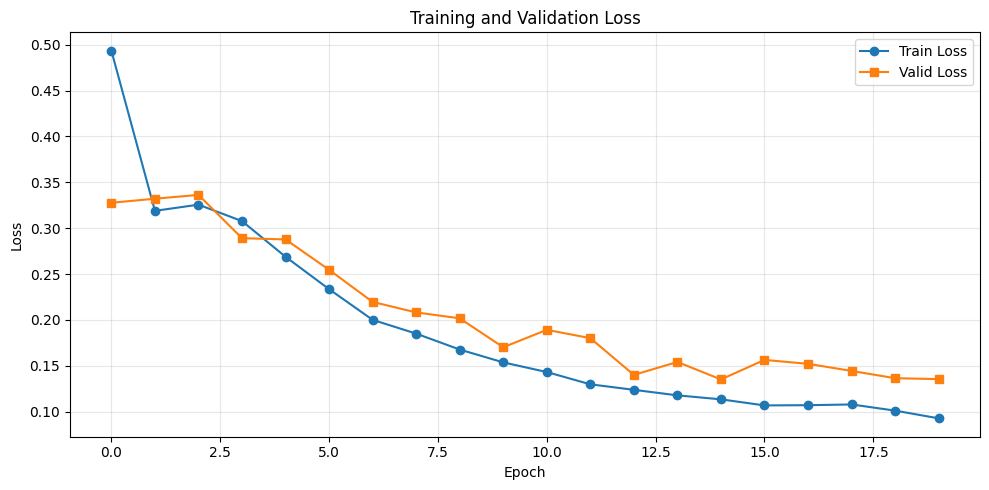

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(valid_losses, label='Valid Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evaluation with COCO Metrics

In [ ]:
model.load_state_dict(torch.load( '/content/drive/MyDrive/colab_runs/FasteRCNN_model/faster_cnn_model_v2.pt'))
model.eval()

In [ ]:
@torch.no_grad()
def get_predictions(model, data_loader, device, score_threshold=0.5):
    model.eval()
    all_predictions = []

    for images, targets in data_loader:
        images = [img.to(device) for img in images]

        with torch.amp.autocast('cuda'):
            outputs = model(images)

        for i, output in enumerate(outputs):
            img_id = targets[i]['image_id'].item()
            mask = output['scores'] >= score_threshold
            boxes = output['boxes'][mask].cpu().numpy()
            scores = output['scores'][mask].cpu().numpy()
            labels = output['labels'][mask].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box
                all_predictions.append({
                    'image_id': img_id,
                    'category_id': int(label),
                    'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                    'score': float(score)
                })

    return all_predictions

test_predictions = get_predictions(model, test_loader, device, score_threshold=0.5)

In [ ]:
if len(test_predictions)>0:
    coco_gt = COCO(test_ann)

    coco_dt = coco_gt.loadRes(test_predictions)

    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()

    print("\n" + "="*60)
    print("COCO Evaluation Metrics")
    print("="*60)
    coco_eval.summarize()
else:
    print("No predictions made. Check model and threshold.")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.34s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.45s).
Accumulating evaluation results...
DONE (t=0.16s).

COCO Evaluation Metrics
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.312
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.434
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.371
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.201
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.322
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.553
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.591
 Average Recall     (AR) @[ IoU=0.50:0.9

## 7. Visualization of Detections

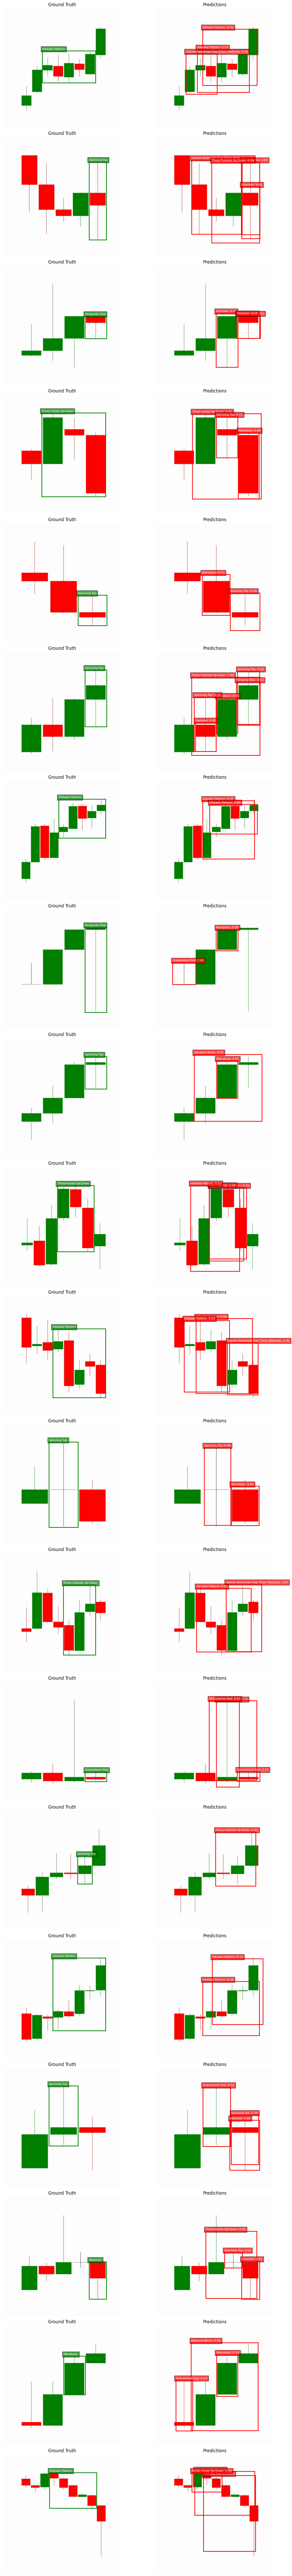

In [ ]:
def visualize_gt_vs_pred(model, dataset, device, num_images=4, score_threshold=0.5):
    """Compare ground truth vs predictions side by side."""
    model.eval()

    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    _, axes = plt.subplots(num_images, 2, figsize=(14, 5 * num_images))

    for row_idx, data_idx in enumerate(indices):
        img_tensor, target = dataset[data_idx]

        with torch.no_grad():
            prediction = model([img_tensor.to(device)])[0]

        img = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        ax_gt = axes[row_idx, 0] if num_images > 1 else axes[0]
        ax_gt.imshow(img)
        ax_gt.set_title('Ground Truth', fontsize=12)
        ax_gt.axis('off')

        for box, label in zip(target['boxes'].numpy(), target['labels'].numpy()):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='green', facecolor='none'
            )
            ax_gt.add_patch(rect)
            ax_gt.text(x1, y1-5, category_names.get(label, '?'),
                      color='white', fontsize=8,
                      bbox=dict(facecolor='green', alpha=0.7))

        ax_pred = axes[row_idx, 1] if num_images > 1 else axes[1]
        ax_pred.imshow(img)
        ax_pred.set_title('Predictions', fontsize=12)
        ax_pred.axis('off')

        pred_boxes = prediction['boxes'].cpu().numpy()
        pred_scores = prediction['scores'].cpu().numpy()
        pred_labels = prediction['labels'].cpu().numpy()

        for box, score, label in zip(pred_boxes, pred_scores, pred_labels):
            if score >= score_threshold:
                x1, y1, x2, y2 = box
                rect = patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax_pred.add_patch(rect)
                ax_pred.text(x1, y1-5, f"{category_names.get(label, '?')}: {score:.2f}",
                           color='white', fontsize=8,
                           bbox=dict(facecolor='red', alpha=0.7))

    plt.tight_layout()
    plt.savefig('gt_vs_pred.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_gt_vs_pred(model, test_dataset, device, num_images=20)

## 8. Save Model and Summary

In [ ]:
# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': NUM_CLASSES,
    'category_names': category_names,
    'train_losses': train_losses,
    'valid_losses': valid_losses
},  '/content/drive/MyDrive/colab_runs/FasteRCNN_model/checkpoint/faster_cnn_model_checkpoint_v2.pt')